<a href="https://colab.research.google.com/github/thanakppm/Project_Python_Retail_Store_Group_4/blob/main/Retail_Store.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Project Python Retail Store Group 4


```
683020241-0 นางสาวณัฏฐ์ปรัศมน ทวีโภควรกุล
683020250-9 นางสาวนรมณ พวงศรีเคน
683020563-8 นางสาวกฤษณา กาลิง
683020572-7 นายธนากร พงษ์เพชร
683020589-0 นางสาวพัชริญา ภูโนนทา
```

In [1]:
# ============================================================
# ระบบจัดการร้านค้าปลีก (Retail Store Management System)
# ============================================================
# ร้านค้าปลีกมีสินค้าอยู่ 2 จุด คือ
# 1. Shelf      = สินค้าที่วางขายให้ลูกค้า
# 2. Warehouse  = สินค้าสำรองหลังร้าน
# เมื่อลูกค้าซื้อสินค้า:
# Customer
#     ↓
# Order
#     ↓
# Payment
#     ↓
# ตัดสินค้าออกจาก Shelf
#     ↓
# ตรวจสอบ Stock
#     ↓
# แจ้งเตือนถ้าสินค้าใกล้หมด
# ============================================================


# ============================================================
# Class: Customer
# ============================================================

import datetime

class Customer:

    def __init__(self, customer_id, name, is_member=False, points=0):
        self.customer_id = customer_id
        self.name = name
        self.is_member = is_member
        self.points = points

    def add_points(self, points):
        # Method นี้ใช้เพิ่มคะแนนให้ลูกค้า
        # โดยจะเพิ่มคะแนนก็ต่อเมื่อเป็นสมาชิกเท่านั้น
        if self.is_member:
            self.points += points

    def customer_info(self):
        # Method นี้ใช้แสดงข้อมูลของลูกค้า
        return {
            "customer_id": self.customer_id,
            "name": self.name,
            "is_member": self.is_member,
            "points": self.points
        }


# ============================================================
# Class: Product
# ============================================================

class Product:

    def __init__(self, product_id, name, category, cost, price):
        self.product_id = product_id
        self.name = name
        self.category = category
        self.cost = cost
        self.price = price

    def get_profit_per_unit(self):
        # คำนวณกำไรต่อสินค้า 1 ชิ้น
        # กำไรต่อหน่วย = ราคาขาย - ต้นทุน
        return self.price - self.cost

    def product_info(self):
        # แสดงข้อมูลของสินค้า
        return {
            "product_id": self.product_id,
            "name": self.name,
            "category": self.category,
            "cost": self.cost,
            "price": self.price,
            "profit": self.get_profit_per_unit()
        }


# ============================================================
# Class: Inventory
# ============================================================
#
# ใช้จัดการ Stock ของสินค้าใน 2 จุด:
#
# Shelf      = สินค้าที่พร้อมขาย
# Warehouse  = สินค้าสำรอง
#
# ระบบจะแยก Stock สองจุดออกจากกัน เพื่อให้เจ้าของร้านรู้ว่า
# สินค้าหมดที่ชั้นวาง หรือสินค้าสำรองในโกดังก็ใกล้หมดแล้ว
# ============================================================

class Inventory:

    def __init__(self):
        # เก็บข้อมูล Stock ของสินค้าแต่ละชนิด
        self.stock = {}

    def add_product(
        self,
        product,
        shelf=0,
        warehouse=0,
        shelf_min=5,              # จุดที่เริ่มเตือนให้เติมสินค้าบนชั้น
        warehouse_min=10     # warehouse_min  = จุดที่เริ่มเตือนให้สั่งสินค้าเพิ่ม
    ):

        self.stock[product.product_id] = {
            "product": product,
            "shelf": shelf,
            "warehouse": warehouse,
            "shelf_min": shelf_min,
            "warehouse_min": warehouse_min
        }

    def restock_shelf(self, product, quantity):
        # Method นี้ใช้ย้ายสินค้าจาก Warehouse
        # มาเติมที่ Shelf
        # สินค้าไม่ได้เพิ่มขึ้นจากการเติมชั้น
        # แต่เป็นการย้ายตำแหน่งของ Stock

        if quantity <= 0:
            print("จำนวนสินค้าต้องมากกว่า 0")
            return False

        if product.product_id not in self.stock:
            print("ไม่พบสินค้าใน Inventory")
            return False

        item = self.stock[product.product_id]

        # ตรวจสอบก่อนว่า Warehouse มีของเพียงพอหรือไม่
        if item["warehouse"] < quantity:
            print("สินค้าในโกดังไม่เพียงพอ")
            return False

        # ย้ายสินค้าจาก Warehouse มาที่ Shelf
        item["warehouse"] -= quantity
        item["shelf"] += quantity
        print(
            f"เติม {product.name} จำนวน {quantity} ชิ้น "
            f"จาก Warehouse → Shelf"
        )

        return True

    def sell_product(self, product, quantity):
        # Method นี้ใช้ตัดสินค้าออกจาก Shelf
        # เมื่อมีการชำระเงินเรียบร้อยแล้ว

        if quantity <= 0:
            print("จำนวนสินค้าต้องมากกว่า 0")
            return False

        if product.product_id not in self.stock:
            print("ไม่พบสินค้าใน Inventory")
            return False

        item = self.stock[product.product_id]

        # ตรวจสอบว่าสินค้าบน Shelf เพียงพอหรือไม่
        if item["shelf"] < quantity:
            print(f"สินค้า {product.name} บนชั้นวางไม่เพียงพอ")
            return False

        # ตัด Stock ออกจาก Shelf
        item["shelf"] -= quantity

        return True

    def can_sell(self, product, quantity):
        # ตรวจสอบ Stock ก่อนการขายจริง
        # Method นี้สำคัญสำหรับป้องกันกรณีที่ Order มีหลายสินค้า
        # แล้วสินค้าบางรายการมีไม่เพียงพอ

        if quantity <= 0:
            return False

        if product.product_id not in self.stock:
            return False

        return self.stock[product.product_id]["shelf"] >= quantity

    def adjust_stock(self, product, shelf=None, warehouse=None):
        # ใช้ปรับ Stock กรณีตรวจนับสินค้าจริงแล้ว
        # พบว่าจำนวนในระบบไม่ตรงกับจำนวนที่มีอยู่จริง
        #
        # เช่น ระบบบันทึกว่ามี 20 ชิ้น
        # แต่ตรวจนับจริงพบว่ามี 18 ชิ้น

        if product.product_id not in self.stock:
            print("ไม่พบสินค้าใน Inventory")
            return False

        item = self.stock[product.product_id]

        # ตรวจสอบไม่ให้ Stock ติดลบ
        if shelf is not None and shelf < 0:
            print("จำนวนสินค้า Shelf ไม่สามารถติดลบได้")
            return False

        if warehouse is not None and warehouse < 0:
            print("จำนวนสินค้า Warehouse ไม่สามารถติดลบได้")
            return False

        # ปรับเฉพาะค่าที่ผู้ใช้ส่งเข้ามา
        if shelf is not None:
            item["shelf"] = shelf

        if warehouse is not None:
            item["warehouse"] = warehouse

        return True

    def check_alert(self):
        # ตรวจสอบสินค้าที่มี Stock ต่ำกว่าจุดที่กำหนด
        # ระบบนี้ช่วยลดภาระเจ้าของร้าน
        # เพราะไม่ต้องเดินตรวจสินค้าเองทุกจุด

        alerts = []

        for item in self.stock.values():

            product = item["product"]

            # ถ้าสินค้าบน Shelf ต่ำกว่าหรือเท่ากับจุดขั้นต่ำ
            # ระบบจะแจ้งเตือนให้เติมสินค้า
            if item["shelf"] <= item["shelf_min"]:
                alerts.append(
                    f"⚠️ {product.name}: "
                    f"Shelf เหลือ {item['shelf']} ชิ้น "
                    f"ควรเติมสินค้า"
                )

            # ถ้าสินค้าใน Warehouse ต่ำกว่าหรือเท่ากับจุดขั้นต่ำ
            # ระบบจะแจ้งเตือนให้สั่งสินค้าเพิ่ม
            if item["warehouse"] <= item["warehouse_min"]:
                alerts.append(
                    f"⚠️ {product.name}: "
                    f"Warehouse เหลือ {item['warehouse']} ชิ้น "
                    f"ควรสั่งสินค้าเพิ่ม"
                )

        return alerts

    def receive_stock(self, product, quantity):
        # Method นี้ใช้จำลองกรณีร้านได้รับสินค้าใหม่
        # จากนั้นสินค้าจะถูกนำเข้า Warehouse

        if quantity <= 0:
            print("จำนวนสินค้าต้องมากกว่า 0")
            return False

        if product.product_id not in self.stock:
            print("ไม่พบสินค้าใน Inventory")
            return False

        self.stock[product.product_id]["warehouse"] += quantity

        print(
            f"รับสินค้า {product.name} "
            f"เข้า Warehouse จำนวน {quantity} ชิ้น"
        )

        return True

    def show_stock(self, product):
        # แสดงจำนวน Stock ของสินค้าทั้ง 2 จุด

        if product.product_id not in self.stock:
            print("ไม่พบสินค้าใน Inventory")
            return

        item = self.stock[product.product_id]

        print(f"\nสินค้า: {product.name}")
        print(f"Shelf: {item['shelf']} ชิ้น")
        print(f"Warehouse: {item['warehouse']} ชิ้น")


# ============================================================
# Class: Order
# ============================================================
# Class นี้แทน "รายการซื้อของลูกค้า 1 ครั้ง"
# หนึ่ง Order สามารถมีสินค้าหลายชนิดได้
# ตอน add_product() ยังไม่ตัด Stock
# เพราะลูกค้าอาจเปลี่ยนใจก่อนชำระเงิน
# Stock จะถูกตัดเมื่อ pay() สำเร็จ
# ============================================================

class Order:
    def __init__(self, order_id, customer, inventory, order_time=None):
        self.order_id = order_id
        self.customer = customer
        self.inventory = inventory
        self.items = []
        self.total = 0
        self.is_paid = False
        self.order_time = order_time

    def add_product(self, product, quantity):

        if self.is_paid:
            print("Order นี้ชำระเงินแล้ว ไม่สามารถเพิ่มสินค้าได้")
            return False

        if quantity <= 0:
            print("จำนวนสินค้าต้องมากกว่า 0")
            return False

        # ตรวจสอบว่า Product มีอยู่ใน Inventory หรือไม่
        if product.product_id not in self.inventory.stock:
            print("ไม่พบสินค้าใน Inventory")
            return False

        # ตรวจสอบว่าสินค้าชนิดเดียวกันถูกเพิ่มใน Order ไปแล้วหรือไม่
        current_quantity = 0

        for item in self.items:
            if item["product"].product_id == product.product_id:
                current_quantity += item["quantity"]

        # ตรวจสอบ Stock รวมของสินค้าชนิดนี้
        # ทั้งหมดที่ลูกค้าต้องการใน Order นี้ต้องไม่เกิน Shelf
        if not self.inventory.can_sell(
            product,
            current_quantity + quantity
        ):
            print(
                f"สินค้า {product.name} บน Shelf "
                f"ไม่เพียงพอสำหรับ Order นี้"
            )
            return False

        # ถ้ามีสินค้าชนิดนี้อยู่แล้ว ให้เพิ่มจำนวน
        for item in self.items:

            if item["product"].product_id == product.product_id:

                item["quantity"] += quantity

                self.total += product.price * quantity

                return True

        # ถ้ายังไม่มีสินค้าใน Order ให้สร้างรายการใหม่
        self.items.append({
            "product": product,
            "quantity": quantity
        })

        # เพิ่มราคาสินค้าเข้าไปในยอดรวม
        self.total += product.price * quantity

        return True

    def remove_product(self, product):
        # ลบสินค้าออกจาก Order
        # สามารถทำได้เฉพาะก่อนชำระเงิน

        if self.is_paid:
            print("Order นี้ชำระเงินแล้ว ไม่สามารถแก้ไขได้")
            return False

        for item in self.items:

            if item["product"].product_id == product.product_id:

                # หักราคาของสินค้านั้นออกจากยอดรวม
                self.total -= (
                    item["product"].price * item["quantity"]
                )

                # ลบสินค้าออกจากรายการ
                self.items.remove(item)

                return True

        print("ไม่พบสินค้านี้ใน Order")
        return False

    def pay(self):
        # Method นี้ใช้ชำระเงิน
        #
        # ลำดับการทำงาน:
        #
        # 1. ตรวจสอบว่า Order ยังไม่ได้จ่าย
        # 2. ตรวจสอบ Stock ของสินค้าทุกตัวก่อน
        # 3. ถ้าทุกอย่างมี Stock เพียงพอ จึงตัด Stock
        # 4. เปลี่ยนสถานะเป็นชำระเงินแล้ว
        #
        # การตรวจสอบทั้งหมดก่อนตัด Stock
        # ช่วยป้องกันปัญหา "ตัด Stock ไปบางรายการแล้ว
        # แต่รายการถัดไปขายไม่ได้"

        if self.is_paid:
            print("Order นี้ชำระเงินไปแล้ว")
            return False

        if len(self.items) == 0:
            print("Order ไม่มีสินค้า")
            return False

        # ----------------------------------------------------
        # ขั้นที่ 1: ตรวจสอบ Stock ของสินค้าทุกตัวก่อน
        # ----------------------------------------------------

        for item in self.items:

            product = item["product"]
            quantity = item["quantity"]

            if not self.inventory.can_sell(product, quantity):

                print(
                    f"ไม่สามารถชำระเงินได้ "
                    f"เพราะสินค้า {product.name} ไม่เพียงพอ"
                )

                # ยังไม่มีการตัด Stock
                return False

        # ----------------------------------------------------
        # ขั้นที่ 2: เมื่อทุกสินค้าผ่านการตรวจสอบแล้ว
        # จึงค่อยตัด Stock จริง
        # ----------------------------------------------------

        for item in self.items:

            product = item["product"]
            quantity = item["quantity"]

            self.inventory.sell_product(
                product,
                quantity
            )

        # เปลี่ยนสถานะเป็นชำระเงินแล้ว
        self.is_paid = True

        # คำนวณคะแนนสมาชิก
        # ตัวอย่างเงื่อนไขของระบบจำลอง:
        # ทุก 50 บาท = 1 คะแนน
        points = int(self.total // 50)

        self.customer.add_points(points)

        print(
            f"ชำระเงิน Order {self.order_id} สำเร็จ "
            f"ยอดรวม {self.total:.2f} บาท"
        )

        return True

    def show_bill(self):
        # แสดงใบเสร็จของ Order

        print("\n" + "=" * 40)
        print(f"Order ID: {self.order_id}")
        print(f"Customer: {self.customer.name}")
        print("=" * 40)

        for item in self.items:

            product = item["product"]
            quantity = item["quantity"]

            subtotal = product.price * quantity

            print(
                f"{product.name} x {quantity} "
                f"= {subtotal:.2f} บาท"
            )

        print("-" * 40)
        print(f"Total: {self.total:.2f} บาท")

        if self.is_paid:
            print("สถานะ: ชำระเงินแล้ว")
        else:
            print("สถานะ: ยังไม่ชำระเงิน")

        print("=" * 40)


# ============================================================
# Class: DailyReport
# ============================================================
# Class นี้ใช้สร้างรายงานยอดขายของ "แต่ละวัน"
#
# ระบบจะรับวันที่ที่ต้องการดู เช่น "2026-08-29"
# แล้วเลือกเฉพาะ Order ที่:
# 1. ชำระเงินแล้ว
# 2. เกิดขึ้นในวันที่ที่เราต้องการ
#
# ทำให้ DailyReport เป็นรายงานของวันนั้นจริง ๆ
# ไม่ใช่การนำ Order ทุกวันมารวมกัน
# ============================================================

class DailyReport:

    def __init__(self, orders, report_date):

        # เก็บรายการ Order ทั้งหมด
        self.orders = orders

        # เก็บวันที่ที่ต้องการสร้างรายงาน
        # ใช้รูปแบบ YYYY-MM-DD
        self.report_date = report_date

    def get_paid_orders(self):
        # เลือกเฉพาะ Order ที่ชำระเงินแล้ว
        # และเกิดขึ้นในวันที่ต้องการรายงาน

        paid_orders = []

        for order in self.orders:

            # ตรวจสอบว่า Order มีวันเวลาหรือไม่
            if order.order_time is None:
                continue

            # แปลงวันเวลาของ Order ให้เป็นวันที่
            # เพื่อใช้เปรียบเทียบกับ report_date
            order_date = order.order_time.strftime("%Y-%m-%d")

            # ต้องเป็น Order ที่ชำระเงินแล้ว
            # และเกิดขึ้นในวันที่ต้องการ
            if order.is_paid and order_date == self.report_date:
                paid_orders.append(order)

        return paid_orders

    def summary(self):
        # สรุปข้อมูลการขายของวันที่กำหนด

        paid_orders = self.get_paid_orders()

        # คำนวณยอดขายรวม
        total_sales = sum(
            order.total
            for order in paid_orders
        )

        # เตรียมตัวแปรสำหรับคำนวณต้นทุน
        total_cost = 0

        # เตรียมตัวแปรสำหรับนับจำนวนสินค้าที่ขาย
        total_items = 0

        # วนดู Order ของวันที่ต้องการทีละรายการ
        for order in paid_orders:

            # ในแต่ละ Order อาจมีสินค้าหลายชนิด
            for item in order.items:

                product = item["product"]
                quantity = item["quantity"]

                # ต้นทุนรวมของสินค้านั้น
                total_cost += product.cost * quantity

                # จำนวนสินค้าที่ขายทั้งหมด
                total_items += quantity

        # กำไร = ยอดขาย - ต้นทุน
        total_profit = total_sales - total_cost

        return {
            "report_date": self.report_date,
            "total_orders": len(paid_orders),
            "total_items": total_items,
            "total_sales": total_sales,
            "total_cost": total_cost,
            "total_profit": total_profit
        }

    def show_summary(self):
        # แสดงรายงานยอดขายของวันที่กำหนด

        result = self.summary()

        print("\n" + "=" * 40)
        print(f"รายงานยอดขายประจำวันที่ {result['report_date']}")
        print("=" * 40)

        print(
            f"จำนวน Order: "
            f"{result['total_orders']}"
        )

        print(
            f"จำนวนสินค้าที่ขาย: "
            f"{result['total_items']} ชิ้น"
        )

        print(
            f"ยอดขายรวม: "
            f"{result['total_sales']:.2f} บาท"
        )

        print(
            f"ต้นทุนรวม: "
            f"{result['total_cost']:.2f} บาท"
        )

        print(
            f"กำไรรวม: "
            f"{result['total_profit']:.2f} บาท"
        )

        print("=" * 40)


In [2]:
# ============================================================
# Simulation: จำลองการขายสินค้า 300 รายการ
# ============================================================
# ส่วนนี้ใช้จำลองเหตุการณ์การซื้อสินค้าของลูกค้า
# โดยให้แต่ละรอบของ Loop แทนการซื้อ 1 Order
#
# ร้านมีสินค้า 15 ชนิด
# - ขนม 10 ชนิด
# - น้ำ 5 ชนิด
#
# ลูกค้าแต่ละคนสามารถซื้อสินค้า 1-4 ชนิด
# และแต่ละชนิดซื้อ 1-4 ชิ้น
#
# หลังจากลูกค้าชำระเงิน:
# 1. ระบบตัด Stock จาก Shelf
# 2. ระบบตรวจสอบ Stock
# 3. ถ้า Shelf ต่ำกว่ากำหนด -> แจ้งเตือน
# 4. จำลองเจ้าของร้านเห็นแจ้งเตือนและเติมของ
# 5. ถ้า Warehouse ต่ำ -> จำลองการรับสินค้าใหม่
# ============================================================


import random
from datetime import datetime, timedelta


# ============================================================
# 1. สร้างรายการสินค้า 15 ชนิด
# ============================================================
# เราจะสร้าง Product แยกเป็น 2 กลุ่ม
# เพื่อให้ข้อมูลมีความหลากหลายเหมือนร้านค้าปลีก
# ============================================================

products = []


# ------------------------------------------------------------
# สร้างขนม 10 ชนิด
# ------------------------------------------------------------

snack_names = [
    "มันฝรั่งทอด",
    "ขนมปังกรอบ",
    "ช็อกโกแลต",
    "เวเฟอร์",
    "คุกกี้",
    "ข้าวเกรียบ",
    "เยลลี่",
    "ถั่วอบ",
    "ขนมแท่ง",
    "เค้ก"
]

for i, name in enumerate(snack_names, start=1):

    # สุ่มต้นทุนของสินค้า
    cost = random.randint(8, 20)

    # กำหนดราคาขายให้สูงกว่าต้นทุน
    price = cost + random.randint(5, 15)

    product = Product(
        product_id=f"S{i:02d}",
        name=name,
        category="ขนม",
        cost=cost,
        price=price
    )

    products.append(product)


# ------------------------------------------------------------
# สร้างน้ำ 5 ชนิด
# ------------------------------------------------------------

water_names = [
    "น้ำดื่ม",
    "น้ำแร่",
    "น้ำอัดลม",
    "ชาเขียว",
    "เครื่องดื่มวิตามิน"
]

for i, name in enumerate(water_names, start=1):

    # สุ่มต้นทุนของเครื่องดื่ม
    cost = random.randint(5, 15)

    # กำหนดราคาขายให้สูงกว่าต้นทุน
    price = cost + random.randint(5, 10)

    product = Product(
        product_id=f"W{i:02d}",
        name=name,
        category="เครื่องดื่ม",
        cost=cost,
        price=price
    )

    products.append(product)


# ============================================================
# 2. เพิ่มสินค้าทั้งหมดเข้าสู่ Inventory
# ============================================================
# สินค้าแต่ละชนิดจะมี Stock อยู่ 2 จุด
#
# Shelf      = สินค้าที่นำออกมาขาย
# Warehouse  = สินค้าสำรอง
#
# กำหนดจุดแจ้งเตือนเอาไว้ด้วย
# ============================================================

inventory = Inventory()

for product in products:

    inventory.add_product(
        product=product,

        # จำนวนเริ่มต้นบน Shelf
        shelf=random.randint(15, 30),

        # จำนวนเริ่มต้นใน Warehouse
        warehouse=random.randint(20, 50),

        # ถ้า Shelf เหลือเท่านี้หรือน้อยกว่า
        # ให้ระบบแจ้งเตือน
        shelf_min=5,

        # ถ้า Warehouse เหลือเท่านี้หรือน้อยกว่า
        # ให้ระบบแจ้งเตือนให้สั่งสินค้าเพิ่ม
        warehouse_min=10
    )


# ============================================================
# 3. สร้างลูกค้า
# ============================================================
# สร้างลูกค้าหลายคนไว้ให้ Simulation สุ่มเลือก
#
# ลูกค้าบางคนเป็นสมาชิก
# ลูกค้าบางคนไม่เป็นสมาชิก
# ============================================================

customers = []

for i in range(1, 51):

    # สุ่มว่าเป็นสมาชิกหรือไม่
    is_member = random.choice([True, False])

    customer = Customer(
        customer_id=f"C{i:03d}",
        name=f"ลูกค้า {i}",
        is_member=is_member
    )

    customers.append(customer)


# ============================================================
# 4. เตรียมตัวแปรสำหรับเก็บ Order
# ============================================================
# หลังจากลูกค้าซื้อสินค้าแต่ละครั้ง
# เราจะเก็บ Order เอาไว้ใน list
#
# ภายหลังข้อมูลเหล่านี้จะนำไปสร้าง CSV
# และวิเคราะห์ด้วย pandas / SQL ได้
# ============================================================

orders = []


# ============================================================
# 5. กำหนดช่วงเวลาสำหรับการจำลอง
# ============================================================
# สมมติว่าร้านเปิดดำเนินการเป็นเวลา 30 วัน
#
# แต่ละ Order จะถูกสุ่มวันและเวลาขึ้นมา
# เพื่อให้ภายหลังสามารถวิเคราะห์ยอดขายตามวันและเวลาได้
# ============================================================

start_date = datetime(2026, 8, 1, 7, 0)


# ============================================================
# 6. Simulation 300 Orders
# ============================================================
# จุดสำคัญ:
# 1 รอบของ Loop = ลูกค้า 1 คนเข้ามาซื้อสินค้า 1 Order
#
# ดังนั้น Loop นี้จะเกิดขึ้น 300 ครั้ง
# และได้ข้อมูล Order อย่างน้อย 300 รายการ
# ============================================================

for i in range(1, 301):

    # --------------------------------------------------------
    # สุ่มลูกค้าที่เข้ามาซื้อ
    # --------------------------------------------------------

    customer = random.choice(customers)


    # --------------------------------------------------------
    # สุ่มวันและเวลาที่ลูกค้าเข้าร้าน
    # --------------------------------------------------------
    # สุ่มตั้งแต่วันที่ 1-30
    # และสุ่มเวลาในช่วงร้านเปิด
    # --------------------------------------------------------

    random_day = random.randint(0, 29)

    random_hour = random.randint(7, 21)

    random_minute = random.randint(0, 59)

    order_time = start_date + timedelta(
        days=random_day,
        hours=random_hour - 7,
        minutes=random_minute
    )


    # --------------------------------------------------------
    # สร้าง Order ใหม่
    # --------------------------------------------------------

    order = Order(
        order_id=f"O{i:04d}",
        customer=customer,
        inventory=inventory,
        order_time=order_time
    )


    # --------------------------------------------------------
    # สุ่มจำนวน "ชนิดสินค้า" ที่ลูกค้าจะซื้อ
    # --------------------------------------------------------
    # ลูกค้าหนึ่งคนอาจซื้อ 1-4 ชนิดสินค้า
    #
    # ตัวอย่าง:
    # น้ำ + ขนม
    # หรือ
    # น้ำ + ขนม + ขนม + เครื่องดื่ม
    # --------------------------------------------------------

    number_of_products = random.randint(1, 4)

    selected_products = random.sample(
        products,
        number_of_products
    )


    # --------------------------------------------------------
    # เพิ่มสินค้าเข้า Order
    # --------------------------------------------------------

    for product in selected_products:

        # สุ่มจำนวนสินค้าที่ลูกค้าซื้อ
        # แต่ละชนิดซื้อ 1-4 ชิ้น
        quantity = random.randint(1, 4)

        # พยายามเพิ่มสินค้าเข้า Order
        order.add_product(
            product,
            quantity
        )


    # --------------------------------------------------------
    # ชำระเงิน
    # --------------------------------------------------------
    # สำคัญ:
    # add_product() ยังไม่ตัด Stock
    #
    # Stock จะถูกตัดเมื่อ pay() สำเร็จ
    # --------------------------------------------------------

    payment_success = order.pay()


    # --------------------------------------------------------
    # ถ้าชำระเงินสำเร็จ
    # จึงเก็บ Order ไว้
    # --------------------------------------------------------

    if payment_success:

        orders.append(order)


        # ====================================================
        # 7. ตรวจสอบ Stock หลังการขาย
        # ====================================================
        # ระบบจะตรวจสอบว่าสินค้าชนิดใดถึงจุดแจ้งเตือน
        # ====================================================

        alerts = inventory.check_alert()


        # ----------------------------------------------------
        # ถ้ามี Alert
        # ----------------------------------------------------

        if alerts:

            # จำลองว่าเจ้าของร้านเห็นข้อความแจ้งเตือนแล้ว
            #
            # จากนั้นตรวจสอบสินค้าที่ต้องดำเนินการ
            for product_id, item in inventory.stock.items():

                product = item["product"]


                # ------------------------------------------------
                # ถ้า Shelf ต่ำกว่าจุดขั้นต่ำ
                # ------------------------------------------------

                if item["shelf"] <= item["shelf_min"]:

                    # ตรวจสอบว่ามีสินค้าใน Warehouse หรือไม่
                    if item["warehouse"] > 0:

                        # ถ้ามีสินค้าใน Warehouse
                        # เจ้าของร้านนำมาเติม Shelf
                        quantity_to_restock = min(
                            10,
                            item["warehouse"]
                        )

                        inventory.restock_shelf(
                            product,
                            quantity_to_restock
                        )


                # ------------------------------------------------
                # ถ้า Warehouse ต่ำกว่าจุดขั้นต่ำ
                # ------------------------------------------------

                if item["warehouse"] <= item["warehouse_min"]:

                    # จำลองว่าร้านสั่งสินค้าใหม่
                    # และได้รับสินค้าเข้ามา
                    #
                    # ในที่นี้สมมติว่าได้รับครั้งละ 30 ชิ้น
                    inventory.receive_stock(
                        product,
                        30
                    )


# ============================================================
# 8. แสดงผลหลังจากจำลองครบ 300 Orders
# ============================================================

print("\n" + "=" * 50)
print("SIMULATION COMPLETE")
print("=" * 50)

print(f"จำนวน Order ที่สร้างสำเร็จ: {len(orders)}")


# ============================================================
# 9. แสดง Stock หลังจบ Simulation
# ============================================================
# เพื่อดูว่าสินค้าแต่ละชนิดเหลือเท่าไร
# หลังจากผ่านการขายและการเติมสินค้าแล้ว
# ============================================================

print("\n===== STOCK หลัง Simulation =====")

for product in products:

    inventory.show_stock(product)


# ============================================================
# 10. สร้างรายงานยอดขาย
# ============================================================
# ตัวอย่างนี้เลือกดูยอดขายของวันที่ 29 สิงหาคม 2026
#
# ในขั้นตอนต่อไปเราสามารถใช้ Order ทั้งหมด
# เพื่อสร้างรายงานหลายวันได้
# ============================================================

report = DailyReport(
    orders,
    "2026-08-29"
)

report.show_summary()

ชำระเงิน Order O0001 สำเร็จ ยอดรวม 180.00 บาท
ชำระเงิน Order O0002 สำเร็จ ยอดรวม 18.00 บาท
ชำระเงิน Order O0003 สำเร็จ ยอดรวม 276.00 บาท
ชำระเงิน Order O0004 สำเร็จ ยอดรวม 188.00 บาท
ชำระเงิน Order O0005 สำเร็จ ยอดรวม 161.00 บาท
ชำระเงิน Order O0006 สำเร็จ ยอดรวม 195.00 บาท
ชำระเงิน Order O0007 สำเร็จ ยอดรวม 253.00 บาท
ชำระเงิน Order O0008 สำเร็จ ยอดรวม 189.00 บาท
ชำระเงิน Order O0009 สำเร็จ ยอดรวม 51.00 บาท
ชำระเงิน Order O0010 สำเร็จ ยอดรวม 97.00 บาท
ชำระเงิน Order O0011 สำเร็จ ยอดรวม 169.00 บาท
ชำระเงิน Order O0012 สำเร็จ ยอดรวม 230.00 บาท
เติม มันฝรั่งทอด จำนวน 10 ชิ้น จาก Warehouse → Shelf
ชำระเงิน Order O0013 สำเร็จ ยอดรวม 202.00 บาท
ชำระเงิน Order O0014 สำเร็จ ยอดรวม 105.00 บาท
ชำระเงิน Order O0015 สำเร็จ ยอดรวม 182.00 บาท
ชำระเงิน Order O0016 สำเร็จ ยอดรวม 164.00 บาท
เติม ขนมแท่ง จำนวน 10 ชิ้น จาก Warehouse → Shelf
ชำระเงิน Order O0017 สำเร็จ ยอดรวม 80.00 บาท
ชำระเงิน Order O0018 สำเร็จ ยอดรวม 68.00 บาท
ชำระเงิน Order O0019 สำเร็จ ยอดรวม 227.00 บาท
ชำระเงิน Order O0020 สำเร็จ ย

In [3]:
# ============================================================
# แปลง Object เป็นตาราง และบันทึกเป็น CSV
# ============================================================

import pandas as pd

# ============================================================
# 1. แปลง Order object เป็น Dictionary
# ============================================================

records = []

for order in orders:

    for item in order.items:
        product = item["product"]                                 # ดึงข้อมูลสินค้าออกจาก Order
        quantity = item["quantity"]                               # จำนวนสินค้าที่ลูกค้าซื้อ
        sales_amount = product.price * quantity             # คำนวณยอดขายของสินค้ารายการนี้
        cost_amount = product.cost * quantity               # คำนวณต้นทุนของสินค้ารายการนี้
        profit = sales_amount - cost_amount                 # คำนวณกำไรของสินค้ารายการนี้


        # สร้างข้อมูล 1 แถวในรูปแบบ Dictionary
        record = {
            # ข้อมูล Order
            "order_id": order.order_id,
            "order_time": order.order_time,

            # ข้อมูลลูกค้า
            "customer_id": order.customer.customer_id,
            "customer_name": order.customer.name,
            "is_member": order.customer.is_member,

            # ข้อมูลสินค้า
            "product_id": product.product_id,
            "product_name": product.name,
            "category": product.category,

            # ข้อมูลการซื้อ
            "quantity": quantity,
            "unit_price": product.price,
            "sales_amount": sales_amount,

            # ข้อมูลต้นทุนและกำไร
            "unit_cost": product.cost,
            "cost_amount": cost_amount,
            "profit": profit
        }
        records.append(record)


# ============================================================
# 2. สร้าง DataFrame
# ============================================================
df = pd.DataFrame(records)
# ============================================================
# 3. ตรวจสอบข้อมูลก่อนบันทึก
# ============================================================

print("จำนวนแถวทั้งหมด:", len(df))
print("\nตัวอย่างข้อมูล:")
print(df.head())


# ============================================================
# 4. บันทึกเป็น CSV
# ============================================================
# index=False เพราะเราไม่ต้องการให้ pandas
# สร้างหมายเลขแถวเพิ่มเข้าไปในไฟล์ CSV
# ============================================================

df.to_csv(
    "retail_transactions.csv",
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 5. ตรวจสอบว่าบันทึกสำเร็จ และ โหลด CSV กลับเข้ามาด้วย pandas
# ============================================================

df_csv = pd.read_csv(
    "retail_transactions.csv"
)

print("\nโหลดไฟล์ CSV กลับเข้าสู่ pandas สำเร็จ")
print("ขนาดข้อมูล:", df_csv.shape)






จำนวนแถวทั้งหมด: 760

ตัวอย่างข้อมูล:
  order_id          order_time customer_id customer_name  is_member  \
0    O0001 2026-08-08 17:39:00        C047     ลูกค้า 47      False   
1    O0001 2026-08-08 17:39:00        C047     ลูกค้า 47      False   
2    O0001 2026-08-08 17:39:00        C047     ลูกค้า 47      False   
3    O0002 2026-08-13 07:21:00        C024     ลูกค้า 24       True   
4    O0003 2026-08-01 19:32:00        C002      ลูกค้า 2      False   

  product_id product_name     category  quantity  unit_price  sales_amount  \
0        S01  มันฝรั่งทอด          ขนม         3          25            75   
1        W01      น้ำดื่ม  เครื่องดื่ม         3          18            54   
2        W03     น้ำอัดลม  เครื่องดื่ม         3          17            51   
3        W01      น้ำดื่ม  เครื่องดื่ม         1          18            18   
4        S09      ขนมแท่ง          ขนม         4          15            60   

   unit_cost  cost_amount  profit  
0         19           57     

In [4]:
# ============================================================
# 6. ตรวจสอบข้อมูลเบื้องต้นด้วย info()
# ============================================================

print("\n===== ข้อมูลเบื้องต้น =====")
df_csv.info()



===== ข้อมูลเบื้องต้น =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 760 entries, 0 to 759
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   order_id       760 non-null    object
 1   order_time     760 non-null    object
 2   customer_id    760 non-null    object
 3   customer_name  760 non-null    object
 4   is_member      760 non-null    bool  
 5   product_id     760 non-null    object
 6   product_name   760 non-null    object
 7   category       760 non-null    object
 8   quantity       760 non-null    int64 
 9   unit_price     760 non-null    int64 
 10  sales_amount   760 non-null    int64 
 11  unit_cost      760 non-null    int64 
 12  cost_amount    760 non-null    int64 
 13  profit         760 non-null    int64 
dtypes: bool(1), int64(6), object(7)
memory usage: 78.1+ KB


In [5]:
# ============================================================
# 7. สถิติเบื้องต้นด้วย describe()
# ============================================================

print("\n===== สถิติเบื้องต้น =====")
df_csv.describe()


===== สถิติเบื้องต้น =====


,quantity,unit_price,sales_amount,unit_cost,cost_amount,profit
count,760.000000,760.000000,760.000000,760.000000,760.000000,760.000000
mean,2.461842,22.082895,54.468421,12.407895,30.655263,23.813158
std,1.079753,5.436879,28.075778,4.430038,18.237479,11.972931
min,1.000000,15.000000,15.000000,5.000000,5.000000,6.000000
25%,2.000000,17.000000,30.000000,9.000000,16.000000,13.000000
50%,3.000000,21.000000,51.000000,12.000000,27.000000,22.000000
75%,3.000000,28.000000,75.000000,15.000000,39.000000,30.000000
max,4.000000,33.000000,132.000000,19.000000,76.000000,56.000000


In [6]:
# ============================================================
# SQLite Database
# ============================================================

import sqlite3
import pandas as pd


# ============================================================
# 1. โหลดข้อมูลจาก CSV
# ============================================================

df_csv = pd.read_csv("retail_transactions.csv")

print("โหลดข้อมูลจาก CSV สำเร็จ")
print("จำนวนแถว:", len(df_csv))


# ============================================================
# 2. สร้าง / เชื่อมต่อ SQLite Database
# ============================================================

conn = sqlite3.connect("retail_store.db")


# ============================================================
# 3. นำข้อมูลจาก CSV เข้า SQLite
# ============================================================

df_csv.to_sql(
    "orders",
    conn,
    if_exists="replace",
    index=False
)

print("\nสร้างตาราง orders ใน SQLite สำเร็จ")


# ============================================================
# 4. ตรวจสอบข้อมูลใน SQLite
# ============================================================

result = pd.read_sql_query("""
    SELECT *
    FROM orders
    LIMIT 10
""", conn)

print("\n===== ตัวอย่างข้อมูลจาก SQLite =====")
result

โหลดข้อมูลจาก CSV สำเร็จ
จำนวนแถว: 760

สร้างตาราง orders ใน SQLite สำเร็จ

===== ตัวอย่างข้อมูลจาก SQLite =====


,order_id,order_time,customer_id,customer_name,is_member,product_id,product_name,category,quantity,unit_price,sales_amount,unit_cost,cost_amount,profit
0,O0001,2026-08-08 17:39:00,C047,ลูกค้า 47,0,S01,มันฝรั่งทอด,ขนม,3,25,75,19,57,18
1,O0001,2026-08-08 17:39:00,C047,ลูกค้า 47,0,W01,น้ำดื่ม,เครื่องดื่ม,3,18,54,9,27,27
2,O0001,2026-08-08 17:39:00,C047,ลูกค้า 47,0,W03,น้ำอัดลม,เครื่องดื่ม,3,17,51,8,24,27
3,O0002,2026-08-13 07:21:00,C024,ลูกค้า 24,1,W01,น้ำดื่ม,เครื่องดื่ม,1,18,18,9,9,9
4,O0003,2026-08-01 19:32:00,C002,ลูกค้า 2,0,S09,ขนมแท่ง,ขนม,4,15,60,8,32,28
5,O0003,2026-08-01 19:32:00,C002,ลูกค้า 2,0,W02,น้ำแร่,เครื่องดื่ม,4,15,60,5,20,40
6,O0003,2026-08-01 19:32:00,C002,ลูกค้า 2,0,S01,มันฝรั่งทอด,ขนม,4,25,100,19,76,24
7,O0003,2026-08-01 19:32:00,C002,ลูกค้า 2,0,S05,คุกกี้,ขนม,2,28,56,18,36,20
8,O0004,2026-08-15 19:17:00,C020,ลูกค้า 20,1,W05,เครื่องดื่มวิตามิน,เครื่องดื่ม,4,19,76,9,36,40
9,O0004,2026-08-15 19:17:00,C020,ลูกค้า 20,1,S07,เยลลี่,ขนม,4,28,112,15,60,52


In [7]:
# ============================================================
# 5. ตรวจสอบจำนวน Order จริง
# ============================================================

result = pd.read_sql_query("""
    SELECT COUNT(DISTINCT order_id) AS total_orders
    FROM orders
""", conn)

print("\n===== จำนวน Order ทั้งหมด =====")
result


===== จำนวน Order ทั้งหมด =====


,total_orders
0,300


In [8]:
# ============================================================
# 6. ตรวจสอบโครงสร้างตาราง
# ============================================================

table_info = pd.read_sql_query("""
    PRAGMA table_info(orders)
""", conn)

print("\n===== โครงสร้างตาราง orders =====")
table_info


===== โครงสร้างตาราง orders =====


,cid,name,type,notnull,dflt_value,pk
0,0,order_id,TEXT,0,None,0
1,1,order_time,TEXT,0,None,0
2,2,customer_id,TEXT,0,None,0
3,3,customer_name,TEXT,0,None,0
4,4,is_member,INTEGER,0,None,0
5,5,product_id,TEXT,0,None,0
6,6,product_name,TEXT,0,None,0
7,7,category,TEXT,0,None,0
8,8,quantity,INTEGER,0,None,0
9,9,unit_price,INTEGER,0,None,0


In [9]:
# ============================================================
# 7. ปิดการเชื่อมต่อ
# ============================================================

conn.close()

print("\nปิดการเชื่อมต่อ SQLite เรียบร้อย")


ปิดการเชื่อมต่อ SQLite เรียบร้อย


In [10]:
# ============================================================
# วิเคราะห์ข้อมูลด้วย Pandas และ SQL
# ============================================================

import pandas as pd
import sqlite3


# ============================================================
# PART 1: วิเคราะห์ด้วย Pandas
# ============================================================

# โหลดข้อมูลจาก CSV ที่สร้างไว้
df = pd.read_csv("retail_transactions.csv")

# แปลง order_time เป็น datetime
df["order_time"] = pd.to_datetime(df["order_time"])


# ------------------------------------------------------------
# 1. สรุปยอดขายตามหมวดสินค้า
# ------------------------------------------------------------

pandas_category = (
    df[df["sales_amount"] > 0]
    .groupby("category")
    .agg(
        total_orders=("order_id", "nunique"),
        total_quantity=("quantity", "sum"),
        total_sales=("sales_amount", "sum")
    )
    .reset_index()
    .sort_values("total_sales", ascending=False)
)

print("===== Pandas: สรุปยอดขายตามหมวดสินค้า =====")
pandas_category

===== Pandas: สรุปยอดขายตามหมวดสินค้า =====


,category,total_orders,total_quantity,total_sales
0,ขนม,262,1139,28237
1,เครื่องดื่ม,206,732,13159


In [11]:
# ------------------------------------------------------------
# 2. สินค้าขายดีที่สุด
# ------------------------------------------------------------

pandas_product = (
    df[df["sales_amount"] > 0]
    .groupby("product_name")
    .agg(
        total_quantity=("quantity", "sum"),
        total_sales=("sales_amount", "sum")
    )
    .reset_index()
    .sort_values("total_quantity", ascending=False)
)

print("\n===== Pandas: สินค้าขายดีที่สุด =====")
pandas_product



===== Pandas: สินค้าขายดีที่สุด =====


,product_name,total_quantity,total_sales
11,เครื่องดื่มวิตามิน,155,2945
9,น้ำแร่,152,2280
7,น้ำดื่ม,149,2682
10,มันฝรั่งทอด,141,3525
4,ชาเขียว,140,2940
0,ขนมปังกรอบ,136,3808
8,น้ำอัดลม,136,2312
13,เยลลี่,117,3276
2,ข้าวเกรียบ,116,1972
14,เวเฟอร์,116,2320


In [12]:
# ------------------------------------------------------------
# 3. ยอดขายรายวัน
# ------------------------------------------------------------

pandas_daily = (
    df[df["sales_amount"] > 0]
    .assign(order_date=df["order_time"].dt.date)
    .groupby("order_date")
    .agg(
        total_orders=("order_id", "nunique"),
        total_sales=("sales_amount", "sum")
    )
    .reset_index()
    .sort_values("order_date")
)

print("\n===== Pandas: ยอดขายรายวัน =====")
pandas_daily


===== Pandas: ยอดขายรายวัน =====


,order_date,total_orders,total_sales
0,2026-08-01,9,1335
1,2026-08-02,5,908
2,2026-08-03,6,777
3,2026-08-04,10,1208
4,2026-08-05,6,729
5,2026-08-06,12,1410
6,2026-08-07,3,318
7,2026-08-08,12,1872
8,2026-08-09,7,792
9,2026-08-10,6,1017


In [13]:
# ============================================================
# PART 2: วิเคราะห์ด้วย SQL
# ============================================================

# เชื่อมต่อ SQLite
conn = sqlite3.connect("retail_store.db")


# ------------------------------------------------------------
# 4. สรุปยอดขายตามหมวดสินค้า
# ------------------------------------------------------------

sql_category = pd.read_sql_query("""
    SELECT
        category,
        COUNT(DISTINCT order_id) AS total_orders,
        SUM(quantity) AS total_quantity,
        SUM(sales_amount) AS total_sales
    FROM orders
    WHERE sales_amount > 0
    GROUP BY category
    ORDER BY total_sales DESC
""", conn)

print("\n===== SQL: สรุปยอดขายตามหมวดสินค้า =====")
sql_category


===== SQL: สรุปยอดขายตามหมวดสินค้า =====


,category,total_orders,total_quantity,total_sales
0,ขนม,262,1139,28237
1,เครื่องดื่ม,206,732,13159


In [14]:
# ------------------------------------------------------------
# 5. สินค้าขายดีที่สุด
# ------------------------------------------------------------

sql_product = pd.read_sql_query("""
    SELECT
        product_name,
        SUM(quantity) AS total_quantity,
        SUM(sales_amount) AS total_sales
    FROM orders
    WHERE sales_amount > 0
    GROUP BY product_name
    ORDER BY total_quantity DESC
""", conn)

print("\n===== SQL: สินค้าขายดีที่สุด =====")
sql_product


===== SQL: สินค้าขายดีที่สุด =====


,product_name,total_quantity,total_sales
0,เครื่องดื่มวิตามิน,155,2945
1,น้ำแร่,152,2280
2,น้ำดื่ม,149,2682
3,มันฝรั่งทอด,141,3525
4,ชาเขียว,140,2940
5,น้ำอัดลม,136,2312
6,ขนมปังกรอบ,136,3808
7,เยลลี่,117,3276
8,เวเฟอร์,116,2320
9,ข้าวเกรียบ,116,1972


In [15]:
# ------------------------------------------------------------
# 6. ยอดขายรายวัน
# ------------------------------------------------------------

sql_daily = pd.read_sql_query("""
    SELECT
        DATE(order_time) AS order_date,
        COUNT(DISTINCT order_id) AS total_orders,
        SUM(sales_amount) AS total_sales
    FROM orders
    WHERE sales_amount > 0
    GROUP BY DATE(order_time)
    ORDER BY order_date
""", conn)

print("\n===== SQL: ยอดขายรายวัน =====")
sql_daily


===== SQL: ยอดขายรายวัน =====


,order_date,total_orders,total_sales
0,2026-08-01,9,1335
1,2026-08-02,5,908
2,2026-08-03,6,777
3,2026-08-04,10,1208
4,2026-08-05,6,729
5,2026-08-06,12,1410
6,2026-08-07,3,318
7,2026-08-08,12,1872
8,2026-08-09,7,792
9,2026-08-10,6,1017


In [16]:
# ============================================================
# 7. ปิดการเชื่อมต่อ
# ============================================================

conn.close()

In [17]:
# ============================================================
# ติดตั้งฟอนต์ภาษาไทย
# ============================================================
import matplotlib, os, shutil
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 1. ติดตั้งฟอนต์ภาษาไทย
!apt-get -y install fonts-thai-tlwg

# 2. ล้าง cache ของ matplotlib เพื่ออัปเดตฟอนต์ใหม่
cache_dir = matplotlib.get_cachedir()
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)

# 3. ลงทะเบียนฟอนต์ใหม่เข้ากับ FontManager
font_path = '/usr/share/fonts/truetype/tlwg/Loma.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)

# 4. ตั้งค่าฟอนต์หลัก
plt.rcParams['font.family'] = 'Loma'
plt.rcParams['axes.unicode_minus'] = False

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-tlwg-garuda fonts-tlwg-garuda-ttf fonts-tlwg-kinnari
  fonts-tlwg-kinnari-ttf fonts-tlwg-laksaman fonts-tlwg-laksaman-ttf
  fonts-tlwg-loma fonts-tlwg-loma-ttf fonts-tlwg-mono fonts-tlwg-mono-ttf
  fonts-tlwg-norasi fonts-tlwg-norasi-ttf fonts-tlwg-purisa
  fonts-tlwg-purisa-ttf fonts-tlwg-sawasdee fonts-tlwg-sawasdee-ttf
  fonts-tlwg-typewriter fonts-tlwg-typewriter-ttf fonts-tlwg-typist
  fonts-tlwg-typist-ttf fonts-tlwg-typo fonts-tlwg-typo-ttf fonts-tlwg-umpush
  fonts-tlwg-umpush-ttf fonts-tlwg-waree fonts-tlwg-waree-ttf
The following NEW packages will be installed:
  fonts-thai-tlwg fonts-tlwg-garuda fonts-tlwg-garuda-ttf fonts-tlwg-kinnari
  fonts-tlwg-kinnari-ttf fonts-tlwg-laksaman fonts-tlwg-laksaman-ttf
  fonts-tlwg-loma fonts-tlwg-loma-ttf fonts-tlwg-mono fonts-tlwg-mono-ttf
  fonts-tlwg-norasi fonts-tlwg-norasi-ttf fo

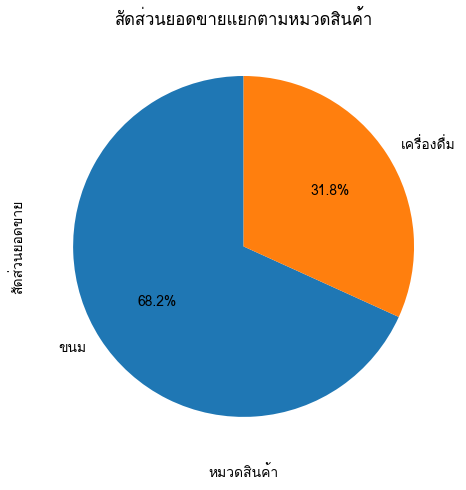

In [18]:
# ============================================================
# PART 1: สร้างกราฟ
# ============================================================

import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. สัดส่วนยอดขายแยกตามหมวดสินค้า
# ------------------------------------------------------------

category_sales = (
    df.groupby("category")["sales_amount"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
category_sales.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("สัดส่วนยอดขายแยกตามหมวดสินค้า")
plt.xlabel("หมวดสินค้า")
plt.ylabel("สัดส่วนยอดขาย")
plt.tight_layout()
plt.show()

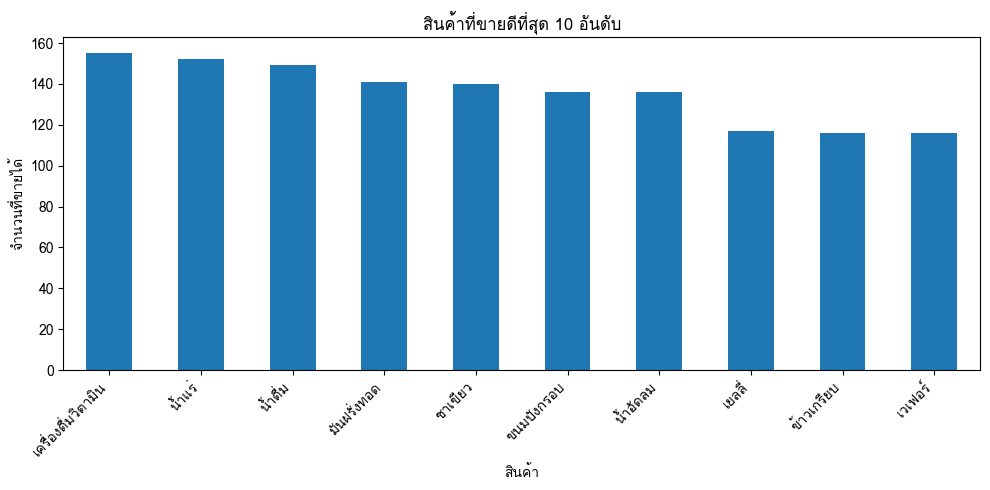

In [19]:
# ------------------------------------------------------------
# 2. สินค้าที่ขายดีที่สุด 10 อันดับ
# ------------------------------------------------------------

product_sales = (
    df.groupby("product_name")["quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
product_sales.plot(kind="bar")

plt.title("สินค้าที่ขายดีที่สุด 10 อันดับ")
plt.xlabel("สินค้า")
plt.ylabel("จำนวนที่ขายได้")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

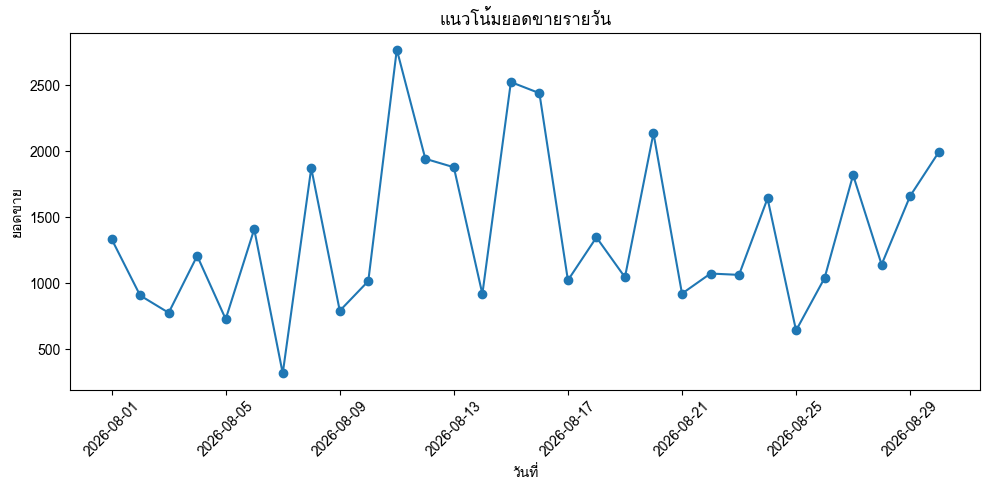

In [20]:
# ------------------------------------------------------------
# 3. แนวโน้มยอดขายรายวัน
# ------------------------------------------------------------

daily_sales = (
    df.groupby(df["order_time"].dt.date)["sales_amount"]
    .sum()
)

plt.figure(figsize=(10, 5))
daily_sales.plot(kind="line", marker="o")

plt.title("แนวโน้มยอดขายรายวัน")
plt.xlabel("วันที่")
plt.ylabel("ยอดขาย")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
# ============================================================
# PART 2: สรุปผลการวิเคราะห์
# ============================================================

best_category = category_sales.idxmax()
best_category_sales = category_sales.max()

best_product = product_sales.idxmax()
best_product_quantity = product_sales.max()

best_day = daily_sales.idxmax()
best_day_sales = daily_sales.max()

total_sales = df["sales_amount"].sum()
total_orders = df["order_id"].nunique()


print("=" * 60)
print("สรุปผลการวิเคราะห์ระบบร้านค้า")
print("=" * 60)

print(f"จำนวน Order ทั้งหมด : {total_orders:,} Orders")
print(f"ยอดขายรวมทั้งหมด    : {total_sales:,.2f} บาท")

print("\n[Business Insight]")

print(
    f"1. หมวดสินค้า {best_category} มียอดขายสูงที่สุด "
    f"คิดเป็น {best_category_sales:,.2f} บาท "
    f"จากยอดขายรวมทั้งหมด"
)

print(
    f"2. สินค้า {best_product} เป็นสินค้าที่ขายดีที่สุด "
    f"โดยมียอดขายจำนวน {best_product_quantity:,} ชิ้น"
)

print(
    f"3. วันที่ {best_day} เป็นวันที่มียอดขายสูงที่สุด "
    f"โดยมียอดขาย {best_day_sales:,.2f} บาท"
)

print(
    f"4. จากข้อมูลจำลองทั้งหมด {total_orders:,} Orders "
    f"ระบบสามารถนำข้อมูลยอดขายและจำนวนสินค้าที่ขายได้ "
    f"มาใช้ประกอบการวางแผน Stock และการจัดโปรโมชั่นได้"
)

print("=" * 60)

สรุปผลการวิเคราะห์ระบบร้านค้า
จำนวน Order ทั้งหมด : 300 Orders
ยอดขายรวมทั้งหมด    : 41,396.00 บาท

[Business Insight]
1. หมวดสินค้า ขนม มียอดขายสูงที่สุด คิดเป็น 28,237.00 บาท จากยอดขายรวมทั้งหมด
2. สินค้า เครื่องดื่มวิตามิน เป็นสินค้าที่ขายดีที่สุด โดยมียอดขายจำนวน 155 ชิ้น
3. วันที่ 2026-08-11 เป็นวันที่มียอดขายสูงที่สุด โดยมียอดขาย 2,770.00 บาท
4. จากข้อมูลจำลองทั้งหมด 300 Orders ระบบสามารถนำข้อมูลยอดขายและจำนวนสินค้าที่ขายได้ มาใช้ประกอบการวางแผน Stock และการจัดโปรโมชั่นได้
